In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Function to find segments of continuous indices
def find_continuous_segments(x):
    segments = []
    current_segment = [x[0]]  # Initialize the first segment

    for i in range(1, len(x)):
        if x[i] == x[i - 1] + 1:
            current_segment.append(x[i])  # Add to current segment if continuous
        else:
            segments.append(current_segment)  # Save current segment
            current_segment = [x[i]]  # Start a new segment

    segments.append(current_segment)  # Add the last segment
    return segments

In [3]:
# function to define and find different branches
'''
proportion of states
basically: average over ccrate mat and irregular mat, but only when it occurs larger than 10% times 
all states: regular oscillation, irregular oscillation, 100% co-contraction, fixed point
rules: 
1. regular oscillation: irflag == 0 and ccrate == 0%
2. irregular oscillation w 0 co-contraction: irflag == 1 and freq!=0 and ccrate ==0
3. irregular oscillation w nonzero co-contraction: irflag == 1 and freq!=0 and 0<ccrate<100%
3. 100% co-contraction (fixed point): irflag == 0 and ccrate == 100%

for each state: if sample number > threshold: averaged over it
record and plot number portion of each state and save
'''
def find_branches(all_data, freq, irflags, ccrate, tol):
     # different branches

    # regular oscillation
    br1 = np.ma.array(all_data, mask=((irflags!=0)|(ccrate>=tol)))

    # irregular oscillation
    br5 = np.ma.array(all_data, mask=((irflags != 1)|(freq==0.0)))

    # irregular oscillation w 0 co-contraction
    br2 = np.ma.array(all_data, mask=((irflags != 1)|(freq==0.0)|(ccrate >= tol)))
    # irregular oscillation w nonzero co-contraction
    br3 = np.ma.array(all_data, mask=((irflags != 1)|(freq==0.0)|(ccrate <= tol)|(ccrate >= 1-tol)))


    # 100% co-contraction (fixed point)
    br4 = np.ma.array(all_data, mask=((ccrate<=1.0-tol)))


    return [br1,br2,br3,br4,br5]
    
    

In [4]:
def set_plots():
    plt.rcParams['xtick.direction'] = 'in'
    plt.rcParams['ytick.direction'] = 'in'
    ax = plt.gca()
    width=2

    ax.spines['bottom'].set_linewidth(width)
    ax.spines['bottom'].set_position('zero')
    ax.spines['left'].set_linewidth(width)

    ax.spines[['right','top']].set_visible(False)
    plt.xticks(fontsize=13)
    plt.yticks(fontsize=13) 

In [31]:
'''
plot frequency modulation with 
> ablation/activation of V2a, V1, V2b, V2a+V1, V2a+V2b
'''
fdname = '../simulation_results/frequency_modulation/w_fc/'

In [6]:
# record number portion of each state for each modulation
state_dict = {}

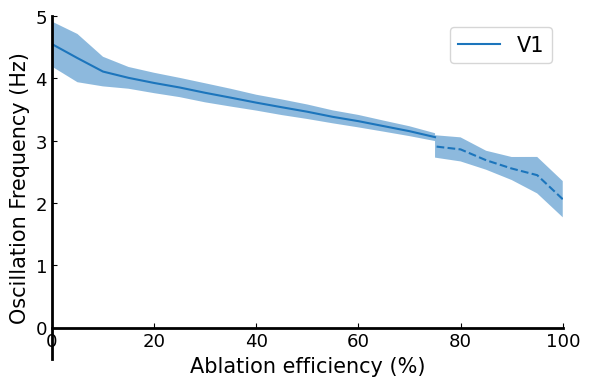

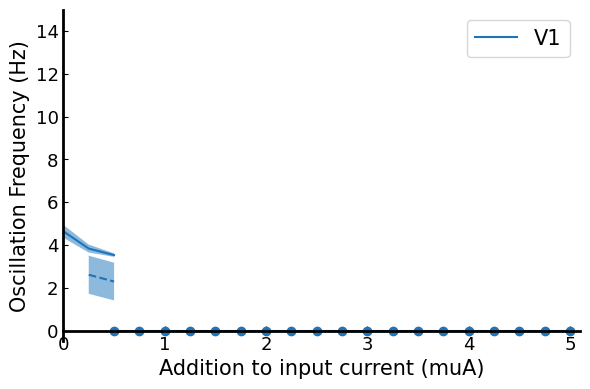

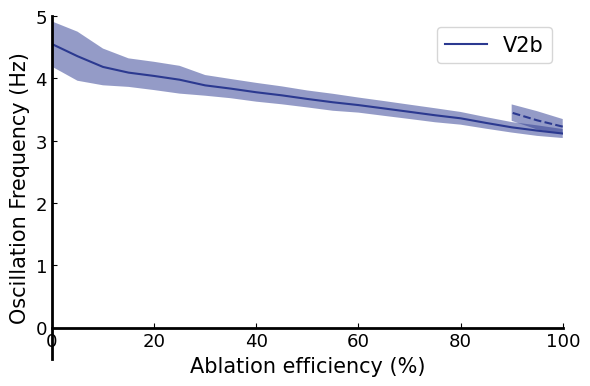

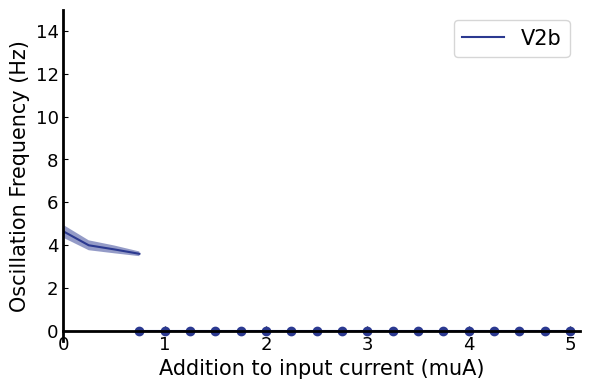

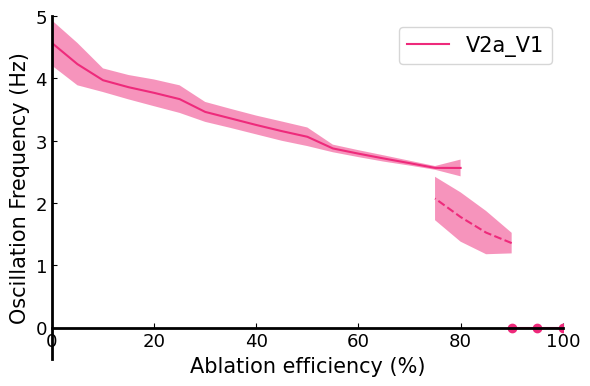

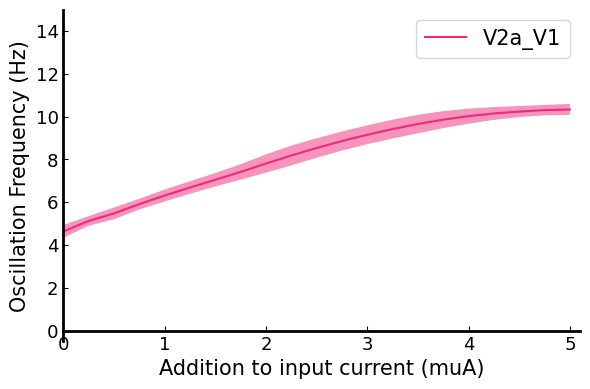

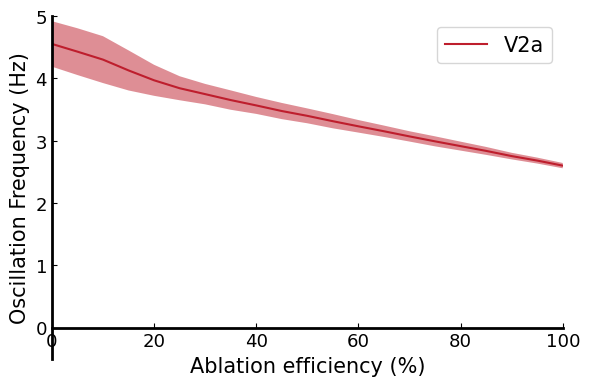

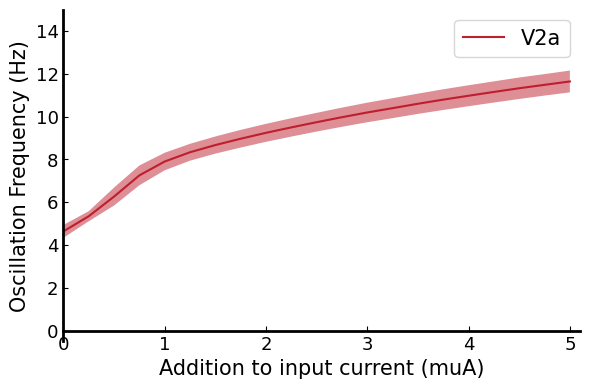

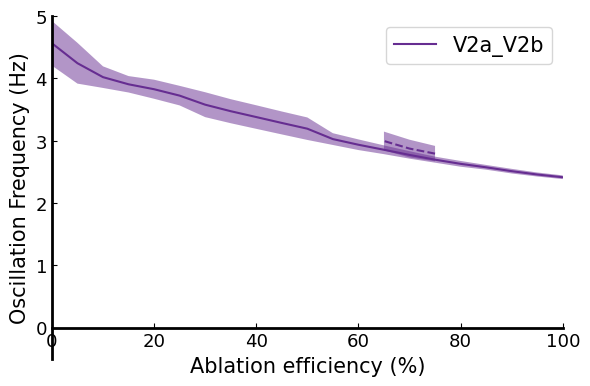

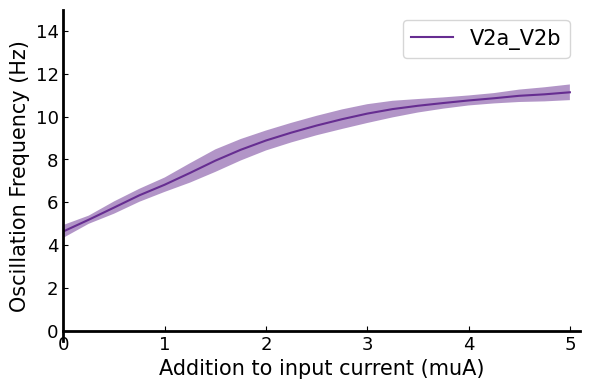

In [7]:
# plot frequency change with noise 


# plt.figure(figsize=(6,4))
Nrep = 50
Npts = 21

for c_ind in ['V1','V2b','V2a_V1','V2a','V2a_V2b']:

    colors = {'V2a':'#BE1E2D','V1':'#1C75BC','V2b':'#2B3990','V2a_V1':'#EE2A7B','V2a_V2b':'#662D91'}


    # select modulation type
    for modulation in ['ablation','activation']:
        plt.figure(figsize=(6,4))

        catname = 'var_%s_mode_%s'%(c_ind,modulation)

        if modulation == 'ablation':
            pararan = np.linspace(1,0,Npts)*100

            all_data = np.loadtxt(fdname+catname+'/%s_%.1f_%.1f_noise_2_%i_%i_jointfreq.txt'% \
                                  (catname,1-pararan[0]/100,1-pararan[-1]/100,Nrep,Npts))
            ccrate = np.loadtxt(fdname+catname+'/%s_%.1f_%.1f_noise_2_%i_%i_ccrate.txt'% \
                                 (catname,1-pararan[0]/100,1-pararan[-1]/100,Nrep,Npts))

            irflags1 = np.loadtxt(fdname+catname+'/%s_%.1f_%.1f_noise_2_%i_%i_irflag_F.txt'% \
                                 (catname,1-pararan[0]/100,1-pararan[-1]/100,Nrep,Npts))
            irflags2 = np.loadtxt(fdname+catname+'/%s_%.1f_%.1f_noise_2_%i_%i_irflag_X.txt'% \
                                 (catname,1-pararan[0]/100,1-pararan[-1]/100,Nrep,Npts))
            irflags = (irflags1+irflags2>0).astype(int)
    #         irflags = irflags2

        elif modulation =='activation':
            pararan = np.linspace(0,5.0,Npts)

            all_data = np.loadtxt(fdname+catname+'/%s_%.1f_%.1f_noise_2_%i_%i_jointfreq.txt'%
                                  (catname,pararan[0],pararan[-1],Nrep,Npts))
            ccrate = np.loadtxt(fdname+catname+'/%s_%.1f_%.1f_noise_2_%i_%i_ccrate.txt'%
                                 (catname,pararan[0],pararan[-1],Nrep,Npts))
            irflags1 = np.loadtxt(fdname+catname+'/%s_%.1f_%.1f_noise_2_%i_%i_irflag_X.txt'%
                                 (catname,pararan[0],pararan[-1],Nrep,Npts))
            irflags2 = np.loadtxt(fdname+catname+'/%s_%.1f_%.1f_noise_2_%i_%i_irflag_F.txt'%
                                 (catname,pararan[0],pararan[-1],Nrep,Npts))
            irflags = (irflags1+irflags2>0).astype(int)
        
        port_thre = 0.14
        brall = find_branches(all_data,all_data,irflags,ccrate,tol=0.01)
        
        # only take branch regular, irregular and 100% cc
        brs = [brall[0],brall[4],brall[3]]
        
        lines = ['-','--','-o']

        state_ = np.concatenate([np.mean(~br_.mask,axis=0) for br_ in brs]).reshape(len(brs),-1)
        state_[state_<port_thre] = 0
        if modulation == 'ablation':
            state_ = state_[:,::-1]
         #
        state_dict[catname] = state_
        
        set_plots()
        
        for ind_,br_ in enumerate(brs):

            error_temp = br_.std(axis=0)
            mean_temp = br_.mean(axis=0)
            para_br = np.where(np.mean(~br_.mask,axis=0)>port_thre)[0]
            if len(para_br)>0:
                segments = find_continuous_segments(para_br)
                ct_ = 0
                for seg_ in segments:
                    if ind_ == 0 and ct_ == 0:
                        plt.plot(pararan[seg_],mean_temp[seg_],lines[ind_],c = colors[c_ind], label = c_ind)
                    else:
                        plt.plot(pararan[seg_],mean_temp[seg_],lines[ind_],c = colors[c_ind], )

                    plt.fill_between(pararan[seg_], mean_temp[seg_]+error_temp[seg_], 
                                 mean_temp[seg_]-error_temp[seg_], 
                                 color = colors[c_ind], alpha = 0.5,edgecolor=None)
                    ct_ += 1
            



        plt.legend(fontsize = 15)
        if modulation == 'ablation':
            plt.xlabel('Ablation efficiency (%)',fontsize=15)
            plt.ylim([-0.5,5.0])
            plt.xlim([0.,100])
        elif modulation == 'activation':
            plt.xlabel('Addition to input current (muA)',fontsize=15)
            plt.ylim([-0.5,15.0])
            plt.xlim([0.,5.1])

        plt.ylabel('Oscillation Frequency (Hz)',fontsize=15)

    #    
        plt.tight_layout()

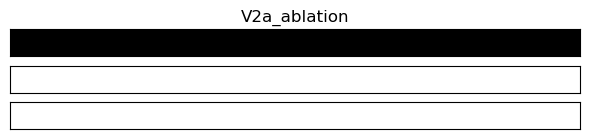

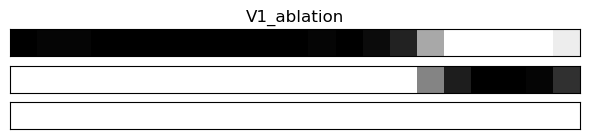

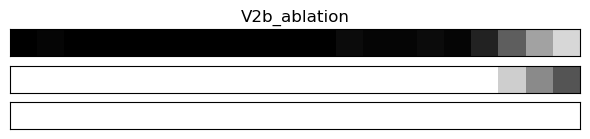

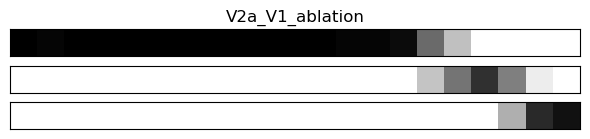

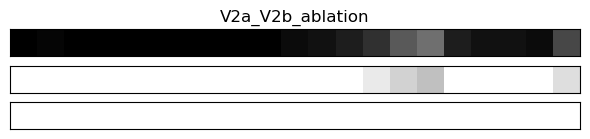

In [14]:
'''
plot proportion of each state
'''

# if combine irregular
state_colors = ['Greys']*4

for c_ind in ['V2a','V1','V2b','V2a_V1','V2a_V2b']:
    
    # select modulation
    modulation = 'ablation'
#     modulation = 'activation'
    
    catname = 'var_%s_mode_%s'%(c_ind,modulation)
    
    mat_ = state_dict[catname]

    
    fig,axs = plt.subplots(len(mat_),1,figsize=(6,1.5))
    for i in range(len(mat_)):
        if catname == 'var_V1_mode_activation' and i ==len(mat_)-1: 
            ci = i+1
        else: ci=i
        im = axs[i].imshow(mat_[i].reshape(1,-1),cmap=state_colors[ci],vmin=0,vmax=1)

        axs[i].tick_params(left = False,bottom=False,labelleft=False,labelbottom=False)
#     fig.colorbar(im, orientation='horizontal')
    axs[0].set_title(c_ind+'_'+modulation)
    plt.tight_layout()


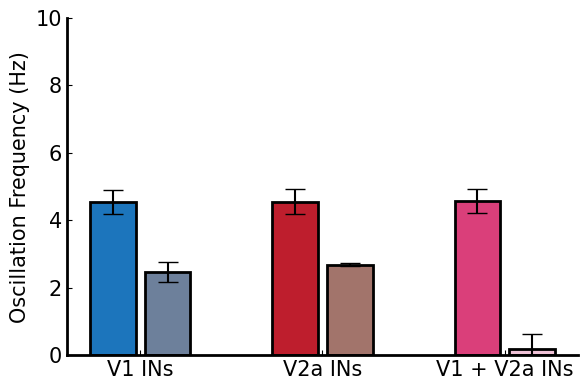

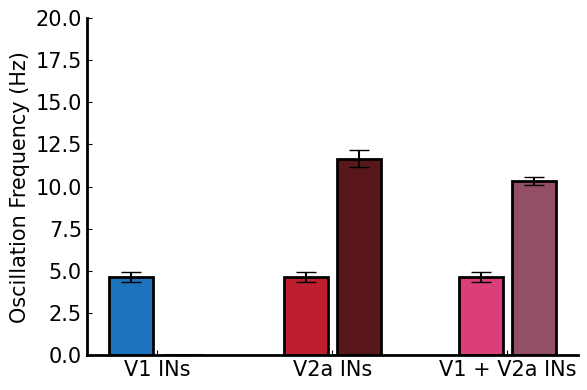

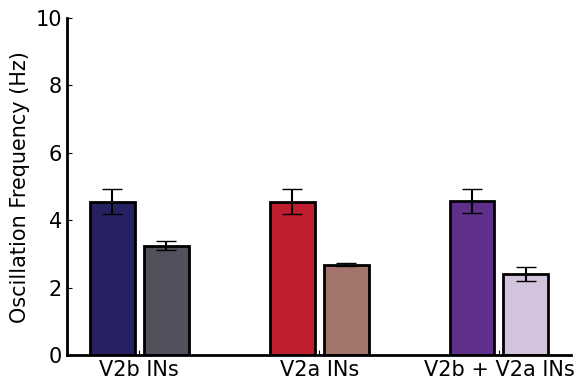

In [15]:
# bar plot of frequency change
# compare 3 bars: V1/V2a abl/act, V2b/V2a abl

colors_3comp = {'V1abl':[['#1C75BC', '#BE1E2D', '#DA3F7A'],['#6D809B', '#A2746B', '#EEC1D6']],
               'V1act':[['#1C75BC', '#BE1E2D', '#DA3F7A'],['#32306C', '#59171A', '#934F63']],
               'V2babl':[['#262262','#BE1E2D','#5E308B'],['#51515D','#A2746B','#D3C3DC']]}

# select which to toplot: 
for toplot in colors_3comp:

    ind = 1
    COND_bars = []
    CTL_bars = []
    COND_err = []
    CTL_err = []
    if toplot == 'V1abl':
        x_names = ['V1 INs','V2a INs','V1 + V2a INs']
        modulation = 'ablation'
        pararan = np.linspace(1,0,20)*100
        for c_ind in ['V1','V2a','V2a_V1']:
            catname = 'var_%s_mode_%s'%(c_ind,modulation)
            all_data = np.loadtxt(fdname+catname+'/%s_%.1f_%.1f_noise_2_50_21_jointfreq.txt'%(catname,1-pararan[0]/100,1-pararan[-1]/100))
            error_temp = np.std(all_data,axis=0)
            mean_temp = np.mean(all_data,axis=0)
            CTL_bars.append(mean_temp[-1])
            CTL_err.append(error_temp[-1])
            COND_bars.append(mean_temp[ind])
            COND_err.append(error_temp[ind])
    elif toplot == 'V1act':
        x_names = ['V1 INs','V2a INs','V1 + V2a INs']
        modulation = 'activation'
        pararan = np.linspace(0,5.0,20)
        for c_ind in ['V1','V2a','V2a_V1']:
            catname = 'var_%s_mode_%s'%(c_ind,modulation)
            all_data = np.loadtxt(fdname+catname+'/%s_%.1f_%.1f_noise_2_50_21_jointfreq.txt'%(catname,pararan[0],pararan[-1]))
            error_temp = np.std(all_data,axis=0)
            mean_temp = np.mean(all_data,axis=0)
            CTL_bars.append(mean_temp[0])
            CTL_err.append(error_temp[0])
            COND_bars.append(mean_temp[-1])
            COND_err.append(error_temp[-1])

    elif toplot == 'V2babl':
        x_names = ['V2b INs','V2a INs','V2b + V2a INs']
        modulation = 'ablation'
        pararan = np.linspace(1,0,20)*100
        for c_ind in ['V2b','V2a','V2a_V2b']:
            catname = 'var_%s_mode_%s'%(c_ind,modulation)
            all_data = np.loadtxt(fdname+catname+'/%s_%.1f_%.1f_noise_2_50_21_jointfreq.txt'%(catname,1-pararan[0]/100,1-pararan[-1]/100))
            error_temp = np.std(all_data,axis=0)
            mean_temp = np.mean(all_data,axis=0)
            CTL_bars.append(mean_temp[-1])
            CTL_err.append(error_temp[-1])
            COND_bars.append(mean_temp[ind])
            COND_err.append(error_temp[ind])

    pos_CTL = np.array([1.4,3.4,5.4])
    pos_COND = np.array([2,4,6])
    pos_label = (pos_CTL+pos_COND)/2

    plt.figure(figsize=(6,4))
    plt.subplot(111)

    plt.bar(pos_CTL, CTL_bars, yerr = CTL_err, label='Control',capsize=7, edgecolor = 'black', \
           linewidth=2,width = 0.5,color=colors_3comp[toplot][0])
    plt.bar(pos_COND, COND_bars, yerr = COND_err, label='Ablated',capsize=7, edgecolor = 'black', \
           linewidth=2,width = 0.5,color=colors_3comp[toplot][1])
    set_plots()
    # Create names on the x-axis
    plt.xticks(pos_label, x_names,fontsize=15)
    plt.yticks(fontsize=15)
    plt.ylabel('Oscillation Frequency (Hz)',fontsize=15)

    # plt.ylim([0,10])
    if toplot[-3:] == 'abl':
        plt.ylim([0,10])
    else:
        plt.ylim([0,20])

    plt.tight_layout()

/var/folders/x4/m6sn1g5s4yjb6ybj1mpz8c600000gn/T/ipykernel_8760/2202476907.py:47: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


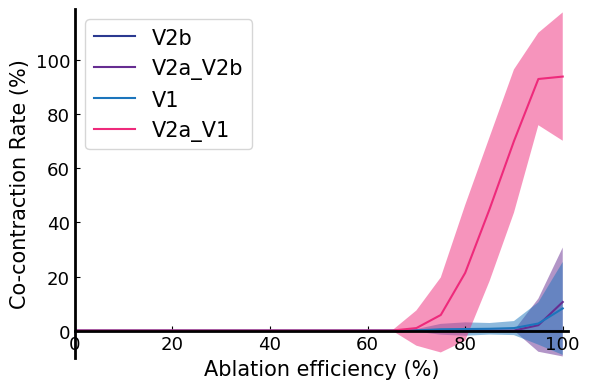

In [12]:
# plot co-contraction rate
#
plt.figure(figsize=(6,4))

for c_ind in ['V2b','V2a_V2b','V1','V2a_V1']:
#     plt.figure(figsize=(6,4))

    colors = {'V2a':'#BE1E2D','V1':'#1C75BC','V2b':'#2B3990','V2a_V1':'#EE2A7B','V2a_V2b':'#662D91'}

    modulation = 'ablation'

    
    catname = 'var_%s_mode_%s'%(c_ind,modulation)
    
    if modulation == 'ablation':
        pararan = np.linspace(1,0,21)*100
        all_data = np.loadtxt(fdname+catname+'/%s_%.1f_%.1f_noise_2_50_21_ccrate.txt'% \
                                  (catname,1-pararan[0]/100,1-pararan[-1]/100))


    error_temp = np.std(all_data,axis=0)*100
    mean_temp = np.mean(all_data,axis=0)*100

    
    
    set_plots()
    # 

    plt.plot(pararan,mean_temp,'-',c = colors[c_ind], label = c_ind)

    plt.fill_between(pararan, mean_temp+error_temp, 
                     mean_temp-error_temp, 
                     color = colors[c_ind], alpha = 0.5,edgecolor=None)
    

    plt.legend(fontsize = 15)
    if modulation == 'ablation':
        plt.xlabel('Ablation efficiency (%)',fontsize=15)
    elif modulation == 'activation':
        plt.xlabel('Addition to input current (muA)',fontsize=15)

    plt.ylabel('Co-contraction Rate (%)',fontsize=15)

    
    plt.ylim([-10,119])
    plt.xlim([0.,101])
    plt.tight_layout()

    

<Figure size 600x400 with 0 Axes>

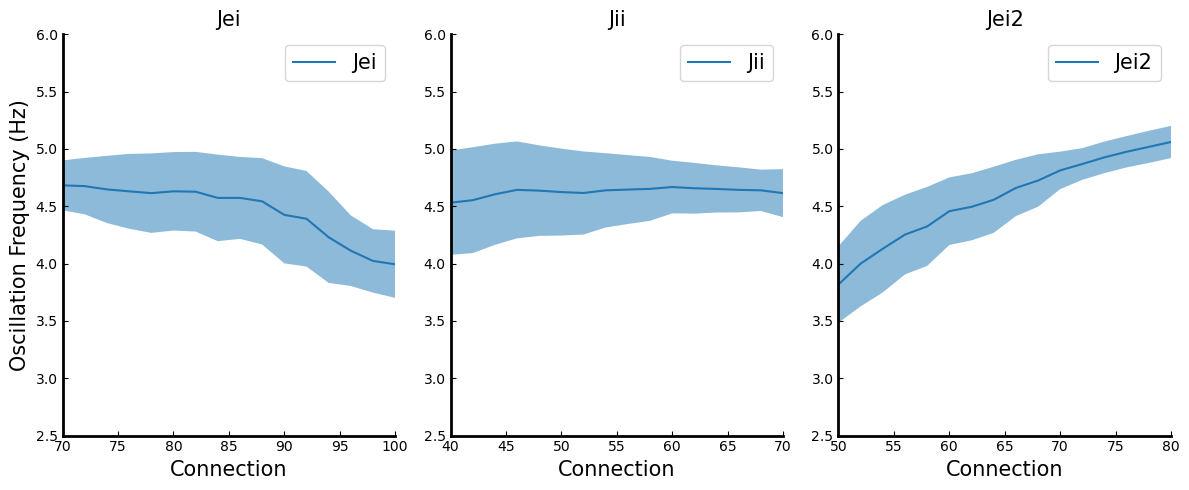

In [20]:
# plot frequency change to modulation of connection
width = 2
fdname = '../simulation_results/frequency_modulation/w_fc/'

plt.figure(figsize=(6,4))

paradict = {'Jei':[60.0,100.0],'Jii':[30.0,70.0],'Jei2':[40.0,80.0]}
rangedict = {'Jei':[70.0,100.0],'Jii':[40.0,70.0],'Jei2':[50.0,80.0]}

fig,ax = plt.subplots(1,3,figsize=(12,5))
ax = ax.flatten()

for i,c_ind in enumerate(paradict.keys()):

    modulation = 'modulation'
    
    catname = 'var_%s_mode_%s'%(c_ind,modulation)
    
    pararan = np.linspace(paradict[c_ind][0],paradict[c_ind][1],21)
    
    all_data = np.loadtxt(fdname+catname+'/%s_%.1f_%.1f_noise_2_50_21_jointfreq.txt'%(catname,pararan[0],pararan[-1]))
    irflags = np.loadtxt(fdname+catname+'/%s_%.1f_%.1f_noise_2_50_21_irflag_F.txt'%(catname,pararan[0],pararan[-1]))
    error_temp = np.std(all_data,axis=0)
    mean_temp = np.mean(all_data,axis=0)

    ax[i].spines['bottom'].set_linewidth(width)
    ax[i].spines['left'].set_linewidth(width)

    ax[i].spines[['right','top']].set_visible(False)

    ax[i].plot(pararan,mean_temp,'-', label = c_ind)

    ax[i].fill_between(pararan, mean_temp+error_temp, mean_temp-error_temp, \
                      alpha = 0.5,edgecolor=None)


    ax[i].legend(fontsize = 15)

    ax[i].set_xlabel('Connection',fontsize=15)

    
    ax[i].set_title(c_ind,fontsize=15)
    
    ax[i].set_ylim([2.5,6.0])
    ax[i].set_xlim(rangedict[c_ind])

ax[0].set_ylabel('Oscillation Frequency (Hz)',fontsize=15)

plt.tight_layout()


In [21]:
# plot frequency change with/without facilitation

fdname = '../simulation_results/frequency_modulation/w_fc/'
fdname_ = '../simulation_results/frequency_modulation/no_fc/'

/var/folders/x4/m6sn1g5s4yjb6ybj1mpz8c600000gn/T/ipykernel_26717/4171055891.py:34: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


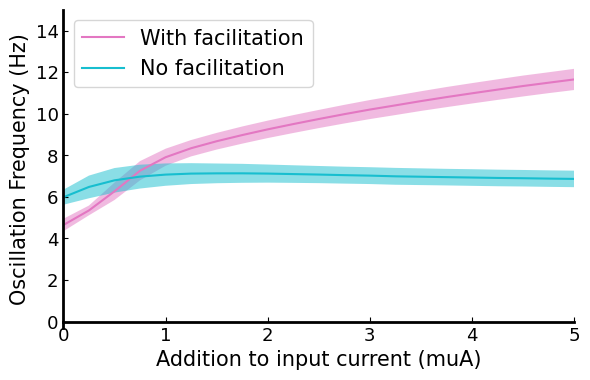

In [22]:
# plot frequency change with noise
#
plt.figure(figsize=(6,4))

for conds in ['With facilitation','No facilitation']:

    colors = {'With facilitation':'tab:pink','No facilitation':'tab:cyan'}

    catname = 'var_%s_mode_%s'%('V2a','activation')
    pararan = np.linspace(0,5.0,21)
    
    if conds == 'With facilitation':
        all_data = np.loadtxt(fdname+catname+'/%s_%.1f_%.1f_noise_2_50_21_jointfreq.txt'%(catname,pararan[0],pararan[-1]))

    elif conds == 'No facilitation':
        all_data = np.loadtxt(fdname_+catname+'/%s_%.1f_%.1f_noise_2_50_21_jointfreq.txt'%(catname,pararan[0],pararan[-1]))


    error_temp = np.std(all_data,axis=0)
    mean_temp = np.mean(all_data,axis=0)

    set_plots()
    # 

    plt.plot(pararan,mean_temp,'-',c = colors[conds], label = conds)
    plt.fill_between(pararan, mean_temp+error_temp, mean_temp-error_temp, \
                     color = colors[conds], alpha = 0.5, edgecolor = None)
    plt.legend(fontsize = 15)

    plt.xlabel('Addition to input current (muA)',fontsize=15)

    plt.ylabel('Oscillation Frequency (Hz)',fontsize=15)

    plt.tight_layout()
    plt.ylim([-0.3,15.0])
    plt.xlim([0,5])

<Figure size 600x400 with 0 Axes>

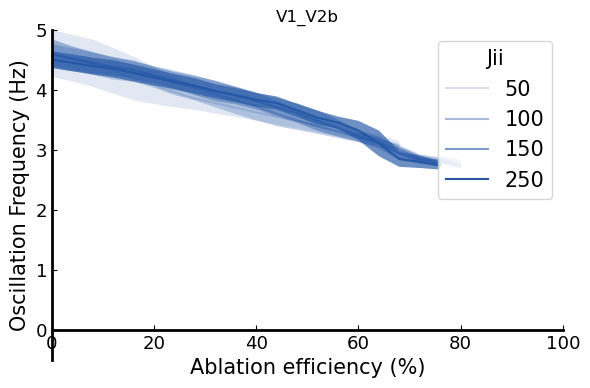

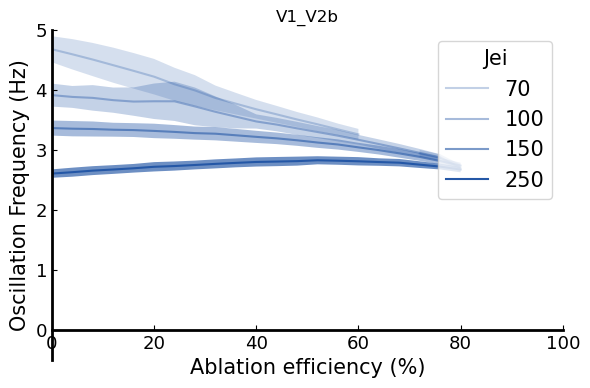

<Figure size 600x400 with 0 Axes>

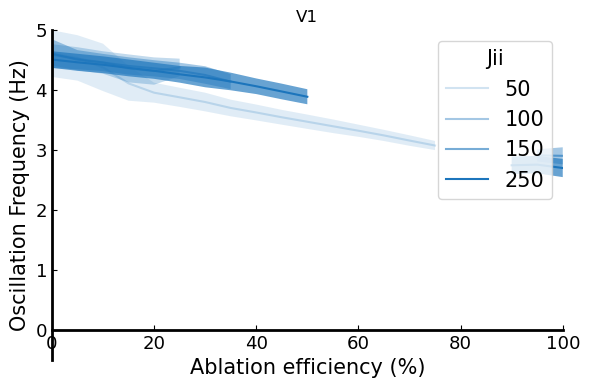

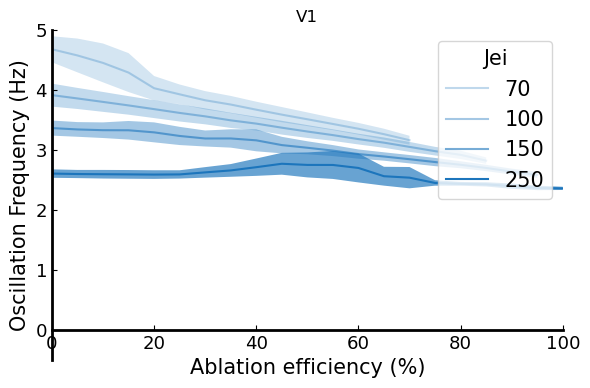

<Figure size 600x400 with 0 Axes>

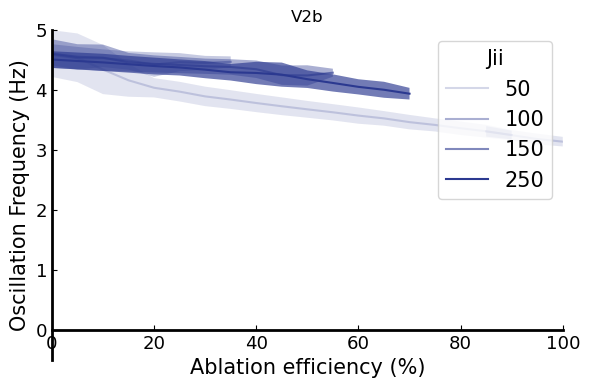

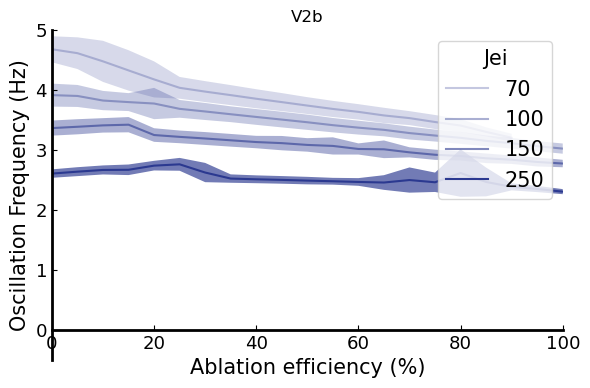

In [33]:
# plot frequency change with ablation under different Jii/Jei values
state_dict = {}
fdname = '../simulation_results/FigS4H_I_5_E_H_inter_inh/'
for c_ind in ['V1_V2b','V1','V2b']:
# for c_ind in ['V1_V2b']:
    plt.figure(figsize=(6,4))
    Nrep = 50
    Npts = 21

    Jname = ['Jii','Jei']
#     Jname= ['Jei']
    Jvalue = {'Jii':[50, 100, 150, 250],'Jei':[70, 100, 150, 250]}
#     Jvalue = [50]

    colors = {'V2a':'#BE1E2D','V1':'#1C75BC','V2b':'#2B3990','V2a_V1':'#EE2A7B','V2a_V2b':'#662D91',
             'V1_V2b':'#2457A6'}

    modulation = 'ablation'
    
    # load different 
    
    for Jn_ in Jname:
        plt.figure(figsize=(6,4))
        for Jv_ in Jvalue[Jn_]:
            
            catname = 'var_%s_mode_%s_%s_%i'%(c_ind,modulation,Jn_,Jv_)
            catname_ = 'var_%s_mode_%s'%(c_ind,modulation)

            if c_ind == 'V1' or c_ind == 'V2b':
                pararan = np.linspace(1.0,0.0,Npts)*100
            else:
                pararan = np.linspace(0.8,0.0,Npts)*100

            all_data = np.loadtxt(fdname+catname_+'/%s_%.1f_%.1f_noise_2_%i_%i_%s_%i_jointfreq.txt'% \
                                  (catname_,1.0-pararan[0]/100,1.0-pararan[-1]/100,Nrep,Npts,Jn_,Jv_))
            ccrate = np.loadtxt(fdname+catname_+'/%s_%.1f_%.1f_noise_2_%i_%i_%s_%i_ccrate.txt'% \
                                 (catname_,1.0-pararan[0]/100,1.0-pararan[-1]/100,Nrep,Npts,Jn_,Jv_))

            irflags1 = np.loadtxt(fdname+catname_+'/%s_%.1f_%.1f_noise_2_%i_%i_%s_%i_irflag_F.txt'% \
                                 (catname_,1.0-pararan[0]/100,1.0-pararan[-1]/100,Nrep,Npts,Jn_,Jv_))
            irflags2 = np.loadtxt(fdname+catname_+'/%s_%.1f_%.1f_noise_2_%i_%i_%s_%i_irflag_X.txt'% \
                                 (catname_,1.0-pararan[0]/100,1.0-pararan[-1]/100,Nrep,Npts,Jn_,Jv_))
            irflags = ((irflags1+irflags2)>0).astype(int)

            
            # only plot regular oscillation
    
            port_thre = 0.14
        
            port_thre = 0.14
            brall = find_branches(all_data,all_data,irflags,ccrate,tol=0.04)

            # only take branch regular, irregular and 100% cc
            brs = [brall[0],brall[4],brall[3]]

            lines = ['-','--','-o']

            state_ = np.concatenate([np.mean(~br_.mask,axis=0) for br_ in brs]).reshape(len(brs),-1)
            state_[state_<port_thre] = 0
            if modulation == 'ablation':
                state_ = state_[:,::-1]
             #
            state_dict[catname] = state_

            set_plots()

            for ind_,br_ in enumerate(brs[:1]):

                error_temp = br_.std(axis=0)
                mean_temp = br_.mean(axis=0)
                para_br = np.where(np.mean(~br_.mask,axis=0)>port_thre)[0]
                
                # if missing point
                segments = find_continuous_segments(para_br)
                ct_ = 0
                for seg_ in segments:
                    if ct_ == 0:
                        plt.plot(pararan[seg_],mean_temp[seg_],lines[ind_], 
                                 color = colors[c_ind], 
                                 alpha = Jv_/250,
                                 label = str(Jv_))
                    else:
                        plt.plot(pararan[seg_],mean_temp[seg_],lines[ind_], 
                                 color = colors[c_ind], 
                                 alpha = Jv_/250,)

                    plt.fill_between(pararan[seg_], mean_temp[seg_]+error_temp[seg_], 
                                 mean_temp[seg_]-error_temp[seg_], 
                                    color = colors[c_ind], 
                                 alpha = Jv_/250/1.5,
                                 edgecolor=None)
                    ct_ += 1
    
        plt.legend(fontsize = 15,title=Jn_,title_fontsize=15,loc='upper right')
        if modulation == 'ablation':
            plt.xlabel('Ablation efficiency (%)',fontsize=15)
            plt.ylim([-0.5,5.0])
            plt.xlim([0.,100])
        elif modulation == 'activation':
            plt.xlabel('Addition to input current (muA)',fontsize=15)
            plt.ylim([-0.5,15.0])
            plt.xlim([0.,5.1])
        # pl.title('I0E = 0.4, I0I\' = 1.4, I0I=1',fontsize=15)
        plt.ylabel('Oscillation Frequency (Hz)',fontsize=15)
        plt.title(c_ind)
    #    
        plt.tight_layout()

/var/folders/x4/m6sn1g5s4yjb6ybj1mpz8c600000gn/T/ipykernel_26717/805191164.py:79: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


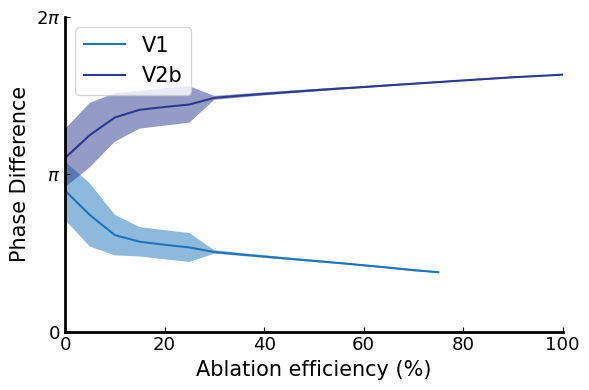

In [28]:
# plot phase difference
fdname = '../simulation_results/FigS5_phase_diff/'
state_dict = {}
plt.figure(figsize=(6,4))
Nrep = 50
Npts = 21
noisestate = 2

for c_ind in ['V1','V2b']:

    colors = {'V2a':'#BE1E2D','V1':'#1C75BC','V2b':'#2B3990','V2a_V1':'#EE2A7B','V2a_V2b':'#662D91'}

    modulation = 'ablation'

    catname = 'var_%s_mode_%s'%(c_ind,modulation)
    
    if modulation == 'ablation':
        pararan = np.linspace(1,0,Npts)*100

        all_data = np.loadtxt(fdname+catname+'/%s_%.1f_%.1f_noise_%i_%i_%i_phasediff.txt'% \
                              (catname,1-pararan[0]/100,1-pararan[-1]/100,noisestate,Nrep,Npts))
        
        freq = np.loadtxt(fdname+catname+'/%s_%.1f_%.1f_noise_%i_%i_%i_jointfreq.txt'% \
                              (catname,1-pararan[0]/100,1-pararan[-1]/100,noisestate,Nrep,Npts))
        
        ccrate = np.loadtxt(fdname+catname+'/%s_%.1f_%.1f_noise_%i_%i_%i_ccrate.txt'% \
                             (catname,1-pararan[0]/100,1-pararan[-1]/100,noisestate,Nrep,Npts))
            
        irflags1 = np.loadtxt(fdname+catname+'/%s_%.1f_%.1f_noise_%i_%i_%i_irflag_F.txt'% \
                             (catname,1-pararan[0]/100,1-pararan[-1]/100,noisestate,Nrep,Npts))
        irflags2 = np.loadtxt(fdname+catname+'/%s_%.1f_%.1f_noise_%i_%i_%i_irflag_X.txt'% \
                             (catname,1-pararan[0]/100,1-pararan[-1]/100,noisestate,Nrep,Npts))
        irflags = (irflags1+irflags2>0).astype(int)
            
    # different branches
    
    port_thre = 0.14

    brall = find_branches(all_data,freq,irflags,ccrate,tol=0.04)

    # only take branch regular, irregular and 100% cc
    brs = [brall[0],brall[4],brall[3]]

    lines = ['-','--','-o']
    
    state_ = np.concatenate([np.mean(~br_.mask,axis=0) for br_ in brs]).reshape(len(brs),-1)
    state_[state_<port_thre] = 0
    if modulation == 'ablation':
        state_ = state_[:,::-1]
     #
    state_dict[catname] = state_
    
    set_plots()

    for ind_,br_ in enumerate(brs[:1]):

        error_temp = br_.std(axis=0)
        mean_temp = br_.mean(axis=0)
        para_br = np.where(np.mean(~br_.mask,axis=0)>port_thre)[0]
        if ind_ == 0:
            plt.plot(pararan[para_br],mean_temp[para_br],lines[ind_],c = colors[c_ind], label = c_ind)
        else:
            plt.plot(pararan[para_br],mean_temp[para_br],lines[ind_],c = colors[c_ind], )
        plt.fill_between(pararan[para_br], mean_temp[para_br]+error_temp[para_br], 
                     mean_temp[para_br]-error_temp[para_br], 
                     color = colors[c_ind], alpha = 0.5,edgecolor=None)

    plt.legend(fontsize = 15)
    if modulation == 'ablation':
        plt.xlabel('Ablation efficiency (%)',fontsize=15)
        plt.yticks([0.0,np.pi,2.0*np.pi],['0','$\pi$','2$\pi$'])
        plt.ylim([0.0,2.0*np.pi])
        plt.xlim([0.,100])
    elif modulation == 'activation':
        plt.xlabel('Addition to input current (muA)',fontsize=15)
        plt.xlim([0.,5.1])
    plt.ylabel('Phase Difference',fontsize=15)

    plt.tight_layout()


/var/folders/x4/m6sn1g5s4yjb6ybj1mpz8c600000gn/T/ipykernel_26717/602341729.py:37: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


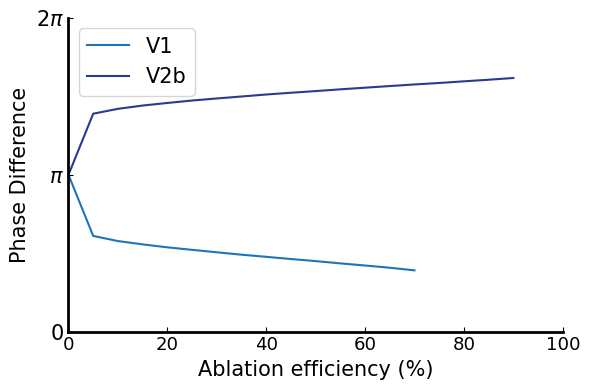

In [29]:
# plot phase difference - no noise

plt.figure(figsize=(6,4))
Nrep = 1
Npts = 21
noisestate = 0

for c_ind in ['V1','V2b']:

    colors = {'V2a':'#BE1E2D','V1':'#1C75BC','V2b':'#2B3990','V2a_V1':'#EE2A7B','V2a_V2b':'#662D91'}

    modulation = 'ablation'   
    catname = 'var_%s_mode_%s'%(c_ind,modulation)
    
    if modulation == 'ablation':
        pararan = np.linspace(1,0,Npts)*100
        all_data = np.loadtxt(fdname+catname+'/%s_%.1f_%.1f_noise_%i_%i_%i_phasediff.txt'% \
                              (catname,1-pararan[0]/100,1-pararan[-1]/100,noisestate,Nrep,Npts))

    all_data  = [None if x == 0 else x for x in all_data]
        
    set_plots()

    plt.plot(pararan,all_data,'-',c = colors[c_ind], label = c_ind)

    plt.legend(fontsize = 15)
    if modulation == 'ablation':
        plt.xlabel('Ablation efficiency (%)',fontsize=15)
        plt.yticks([0.0,np.pi,2.0*np.pi],['0','$\pi$','2$\pi$'],fontsize=15)
        plt.ylim([0.0,2.0*np.pi])
        plt.xlim([0.,100])
    elif modulation == 'activation':
        plt.xlabel('Addition to input current (muA)',fontsize=15)
        plt.xlim([0.,5.1])
    plt.ylabel('Phase Difference',fontsize=15)
  
    plt.tight_layout()